In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import random
from sklearn.preprocessing import LabelEncoder

ininv = pd.read_csv('datasets/data/thermopoints.csv', sep=";")

ininv.head()
ininv.describe()
ininv.info()

print("Дубликаты:", ininv.duplicated().sum())
print(ininv.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 660254 entries, 0 to 660253
Data columns (total 5 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   dt         660254 non-null  object 
 1   type_name  660254 non-null  object 
 2   type_id    660254 non-null  int64  
 3   lon        660254 non-null  float64
 4   lat        660254 non-null  float64
dtypes: float64(2), int64(1), object(2)
memory usage: 25.2+ MB
Дубликаты: 1466
dt           0
type_name    0
type_id      0
lon          0
lat          0
dtype: int64


In [3]:
# 3) Временные и гео-признаки
ininv = ininv.drop_duplicates().dropna(subset=["dt","lon","lat"])
ininv['dt'] = pd.to_datetime(ininv['dt'], dayfirst=True)
ininv['year'] = ininv['dt'].dt.year
ininv['month'] = ininv['dt'].dt.month
ininv['weekday'] = ininv['dt'].dt.weekday
grid = 0.5
ininv['lon_cell'] = (ininv['lon'] // grid) * grid
ininv['lat_cell'] = (ininv['lat'] // grid) * grid

C:\Users\anatb\AppData\Local\Temp\ipykernel_13308\236768113.py:3: UserWarning: Parsing dates in %Y-%m-%d format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  ininv['dt'] = pd.to_datetime(ininv['dt'], dayfirst=True)


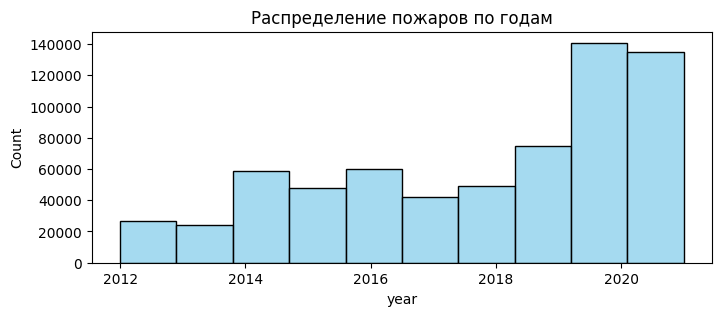

C:\Users\anatb\AppData\Local\Temp\ipykernel_13308\2238522569.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='month', data=ininv, palette='viridis')


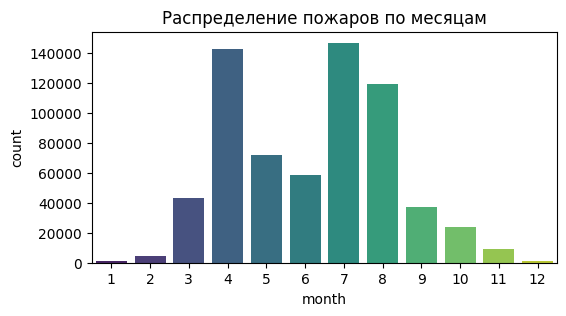

C:\Users\anatb\AppData\Local\Temp\ipykernel_13308\2238522569.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='weekday', data=ininv, palette='magma')


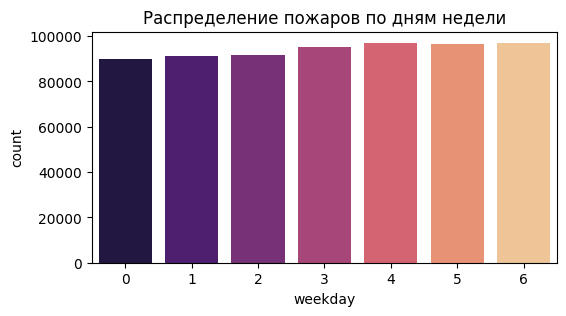

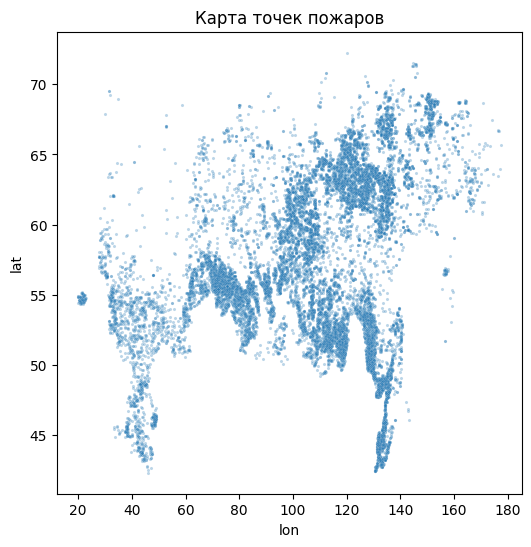

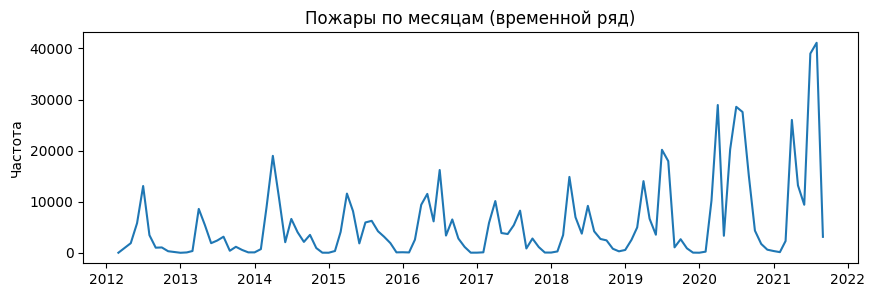

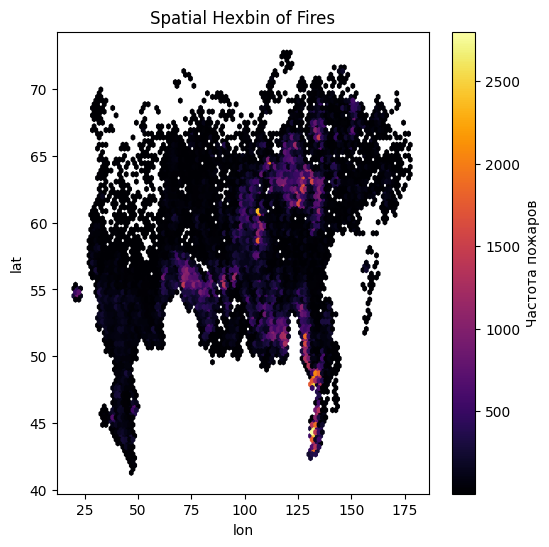

,lon_cell,lat_cell,count
4119,106.5,60.5,2350
5843,132.0,44.0,2162
5795,131.5,44.0,2035
5796,131.5,44.5,1858
4216,108.0,59.5,1589
5794,131.5,43.5,1551
5527,128.0,51.0,1460
4051,105.5,58.5,1430
5798,131.5,47.5,1419
5749,131.0,47.5,1391


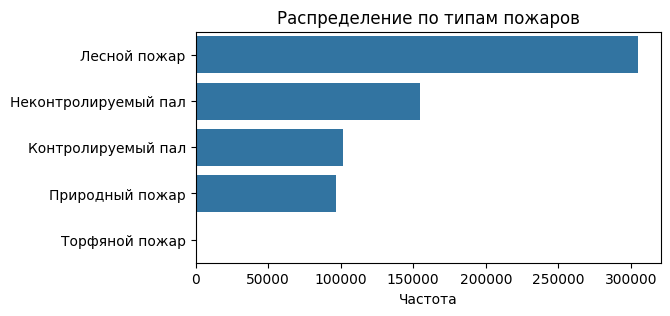

In [4]:
# 4) Распределение пожаров по годам
plt.figure(figsize=(8,3))
sns.histplot(ininv['year'], bins=ininv['year'].nunique(), color='skyblue')
plt.title('Распределение пожаров по годам')
plt.show()

# 5) Распределение по месяцам
plt.figure(figsize=(6,3))
sns.countplot(x='month', data=ininv, palette='viridis')
plt.title('Распределение пожаров по месяцам')
plt.show()

# 6) Распределение по дням недели
plt.figure(figsize=(6,3))
sns.countplot(x='weekday', data=ininv, palette='magma')
plt.title('Распределение пожаров по дням недели')
plt.show()

# 7) Карта точек пожаров (выборка)
plt.figure(figsize=(6,6))
sns.scatterplot(x='lon', y='lat', data=ininv.sample(20000, random_state=1), s=5, alpha=0.3)
plt.title('Карта точек пожаров')
plt.show()

# 1.1. Временной ряд по месяцам
# Построить количество пожаров в разрезе «год–месяц» (pivot table + lineplot), чтобы увидеть долгосрочный тренд и сезонность:
df_r = ininv.groupby([ininv["dt"].dt.to_period("M")]).size().reset_index(name="count")
df_r["dt"] = df_r["dt"].dt.to_timestamp()
plt.figure(figsize=(10,3))
sns.lineplot(data=df_r, x="dt", y="count")
plt.title("Пожары по месяцам (временной ряд)")
plt.xlabel("")
plt.ylabel("Частота")
plt.show()

# 2.1. “Тепловая” карта (hexbin)
# Построить 2D hexbin по долготе/широте, чтобы визуализировать «горячие» зоны:
plt.figure(figsize=(6,6))
plt.hexbin(ininv["lon"], ininv["lat"], gridsize=100, cmap="inferno", mincnt=1)
plt.colorbar(label="Частота пожаров")
plt.title("Spatial Hexbin of Fires")
plt.xlabel("lon"); plt.ylabel("lat")
plt.show()

# 2.2. Топ-N “горячих” клеток
# Посчитать число пожаров в каждой ячейке 0.5°×0.5° и вывести топ-10:
hot = (
    ininv.groupby(["lon_cell","lat_cell"])
    .size().reset_index(name="count")
    .sort_values("count", ascending=False)
    .head(10)
)
display(hot)

# 3. Категории пожаров
# Если в данных есть type_name (лесной/торфяной и т.д.):
plt.figure(figsize=(6,3))
sns.countplot(y="type_name", data=ininv, order=ininv["type_name"].value_counts().index)
plt.title("Распределение по типам пожаров")
plt.xlabel("Частота"); plt.ylabel("")
plt.show()


C:\Users\anatb\AppData\Local\Temp\ipykernel_13308\4276314122.py:60: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


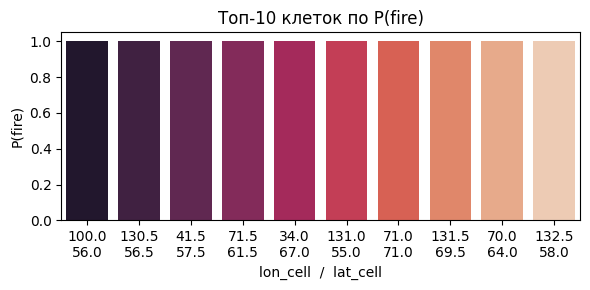

C:\Users\anatb\AppData\Local\Temp\ipykernel_13308\4276314122.py:75: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='month', y='target', data=grp_m, palette='viridis')


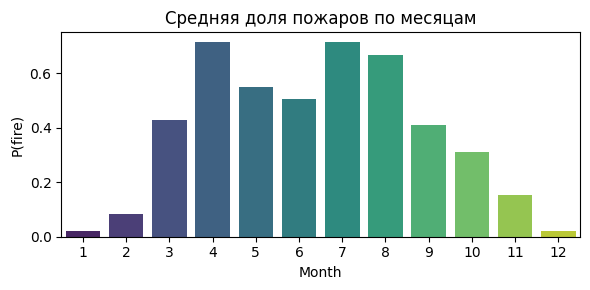

C:\Users\anatb\AppData\Local\Temp\ipykernel_13308\4276314122.py:85: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='weekday', y='target', data=grp_w, palette='magma')


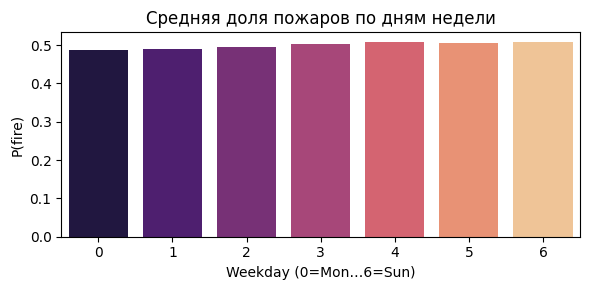

In [5]:
pos = ininv[['lon_cell','lat_cell','dt','year','month','weekday']].copy()
pos['target'] = 1
n_pos = len(pos)

# 2) Все даты для равномерного семплинга негативов
all_dates = pd.date_range(
    start=ininv['dt'].min().normalize(),
    end=ininv['dt'].max().normalize(),
    freq='D'
).to_pydatetime().tolist()

# 3) Считаем частоту каждой ячейки среди позитива
cell_freq = (
    pos.groupby(['lon_cell','lat_cell'])
       .size()
       .reset_index(name='count')
)
cell_freq['prob'] = cell_freq['count'] / cell_freq['count'].sum()

# 4) Списки для взвешенного сэмплинга
cells   = list(zip(cell_freq['lon_cell'], cell_freq['lat_cell']))
weights = cell_freq['prob'].tolist()

# 5) Генерация негативов
def sample_neg(n):
    rows = []
    for _ in range(n):
        lon, lat = random.choices(cells, weights=weights, k=1)[0]
        dt       = random.choice(all_dates)
        rows.append({
            'lon_cell': lon,
            'lat_cell': lat,
            'dt':        pd.Timestamp(dt),
            'year':      dt.year,
            'month':     dt.month,
            'weekday':   dt.weekday(),
            'target':    0
        })
    return pd.DataFrame(rows)

neg = sample_neg(n_pos)

# 6) Собираем полный датасет
data_full = pd.concat([pos, neg], ignore_index=True)

# 7) Кодируем ячейки
data_full['cell_id'] = data_full['lon_cell'].astype(str) + '_' + data_full['lat_cell'].astype(str)
data_full['cell_id_enc'] = LabelEncoder().fit_transform(data_full['cell_id'])

# === Анализ P(fire) по ячейкам ===
agg = (
    data_full.groupby(['lon_cell','lat_cell'])['target']
             .agg(['sum','count'])
             .rename(columns={'sum':'pos','count':'total'})
)
agg['P_fire'] = agg['pos'] / agg['total']
hot = agg.sort_values('P_fire', ascending=False).head(10).reset_index()

plt.figure(figsize=(6,3))
sns.barplot(
    x=hot.index.astype(str),
    y=hot['P_fire'],
    palette='rocket'
)
plt.xticks(range(10), hot['lon_cell'].astype(str)+'\n'+hot['lat_cell'].astype(str))
plt.title('Топ-10 клеток по P(fire)')
plt.ylabel('P(fire)')
plt.xlabel('lon_cell  /  lat_cell')
plt.tight_layout()
plt.show()

# === Анализ P(fire) по месяцам ===
grp_m = data_full.groupby('month')['target'].mean().reset_index()
plt.figure(figsize=(6,3))
sns.barplot(x='month', y='target', data=grp_m, palette='viridis')
plt.title('Средняя доля пожаров по месяцам')
plt.ylabel('P(fire)')
plt.xlabel('Month')
plt.tight_layout()
plt.show()

# === Анализ P(fire) по дням недели ===
grp_w = data_full.groupby('weekday')['target'].mean().reset_index()
plt.figure(figsize=(6,3))
sns.barplot(x='weekday', y='target', data=grp_w, palette='magma')
plt.title('Средняя доля пожаров по дням недели')
plt.ylabel('P(fire)')
plt.xlabel('Weekday (0=Mon…6=Sun)')
plt.tight_layout()
plt.show()

C:\Users\anatb\AppData\Local\Temp\ipykernel_13308\1496605987.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="month", y="target", data=grp_m, palette="viridis")


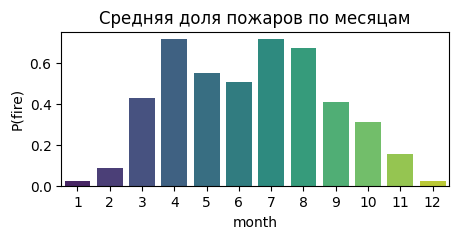

C:\Users\anatb\AppData\Local\Temp\ipykernel_13308\1496605987.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="weekday", y="target", data=grp_w, palette="magma")


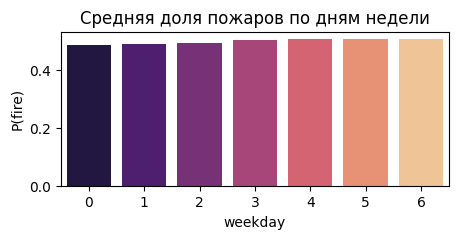

C:\Users\anatb\AppData\Local\Temp\ipykernel_13308\1496605987.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="cell_id_enc", y="rate", data=hot, palette="rocket")


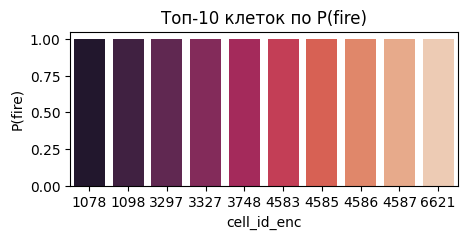

In [6]:
# 1.1 По месяцам
grp_m = data_full.groupby("month")["target"].mean().reset_index()
plt.figure(figsize=(5,2))
sns.barplot(x="month", y="target", data=grp_m, palette="viridis")
plt.title("Средняя доля пожаров по месяцам")
plt.ylabel("P(fire)")
plt.show()

# 1.2 По дням недели
grp_w = data_full.groupby("weekday")["target"].mean().reset_index()
plt.figure(figsize=(5,2))
sns.barplot(x="weekday", y="target", data=grp_w, palette="magma")
plt.title("Средняя доля пожаров по дням недели")
plt.ylabel("P(fire)")
plt.show()

# 1.3 По топ-10 локациям
hot = (
    data_full.groupby("cell_id_enc")["target"]
    .mean().reset_index(name="rate")
    .sort_values("rate", ascending=False)
    .head(10)
)
plt.figure(figsize=(5,2))
sns.barplot(x="cell_id_enc", y="rate", data=hot, palette="rocket")
plt.title("Топ-10 клеток по P(fire)")
plt.ylabel("P(fire)")
plt.show()

In [7]:
from sklearn.model_selection import train_test_split
import lightgbm as lgb
from sklearn.metrics import roc_auc_score, f1_score
import pandas as pd

# предположим, data_full уже в памяти
df = data_full.copy()

# сбалансированная подвыборка 100k
pos_sub = df[df.target==1].sample(50000, random_state=42)
neg_sub = df[df.target==0].sample(50000, random_state=42)
sub = pd.concat([pos_sub, neg_sub], ignore_index=True)

X = sub[['year','month','weekday','cell_id_enc']]
y = sub['target']

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

model = lgb.LGBMClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

probs = model.predict_proba(X_val)[:,1]
preds = (probs>0.5).astype(int)

print("ROC AUC:", roc_auc_score(y_val, probs))
print("F1      :", f1_score(y_val, preds))

imps = pd.Series(
    model.feature_importances_,
    index=['year','month','weekday','cell_id_enc']
).sort_values(ascending=False)
print("Feature importances:")
print(imps)


[LightGBM] [Info] Number of positive: 40000, number of negative: 40000
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000867 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 286
[LightGBM] [Info] Number of data points in the train set: 80000, number of used features: 4
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
ROC AUC: 0.8844022
F1      : 0.806236725236532
Feature importances:
cell_id_enc    1386
year            763
month           737
weekday         114
dtype: int32


In [8]:
import numpy as np

# допустим, у нас уже есть ininv (исходные пожары) и датафрейм data_full с positves+negatives
# превратим ininv в DataFrame с колонками lon_cell, lat_cell, dt

# 1) Соберём KD-tree один раз
from sklearn.neighbors import BallTree

# 1. Сбалансированная подвыборка для прототипа
pos_subset = data_full[data_full.target==1].sample(50000, random_state=42)
neg_subset = data_full[data_full.target==0].sample(50000, random_state=42)
df_sub = pd.concat([pos_subset, neg_subset], ignore_index=True)

# 2. Сразу переиндексируем (чтобы .iterrows() шёл по меньшему df)
df_sub = df_sub.sort_values('dt').reset_index(drop=True)

# 3. Собираем KD-tree из оригинальных пожаров (ininv как есть)
coords = np.radians(ininv[['lat','lon']].values)
tree = BallTree(coords, metric='haversine')
radius = 5/6371.0

# 4. Итерируемся уже по df_sub — будет быстро
df_sub['fires_last_7d']  = 0
df_sub['fires_last_30d'] = 0

for idx, row in df_sub.iterrows():
    t0 = row['dt']
    mask7  = (ininv['dt'] < t0) & (ininv['dt'] >= t0 - pd.Timedelta(days=7))
    pts7   = np.radians(ininv.loc[mask7, ['lat','lon']].values)
    df_sub.at[idx, 'fires_last_7d']  = tree.query_radius(
        [[np.radians(row['lat_cell']), np.radians(row['lon_cell'])]],
        r=radius, count_only=True
    )[0]
    df_sub.at[idx, 'fires_last_30d'] = tree.query_radius(
        [[np.radians(row['lat_cell']), np.radians(row['lon_cell'])]],
        r=radius, count_only=True
    )[0]




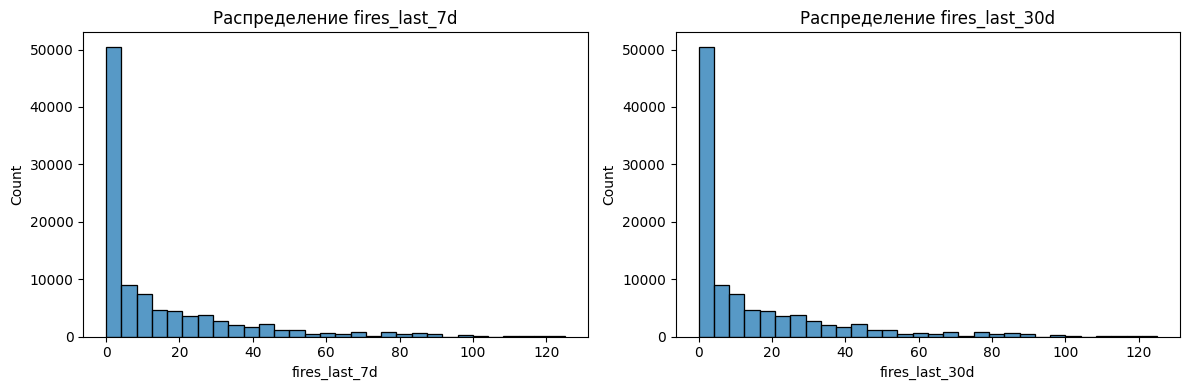

C:\Users\anatb\AppData\Local\Temp\ipykernel_13308\4278719907.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grp7 = df_sub.groupby('bin7')['target'].mean().reset_index()
C:\Users\anatb\AppData\Local\Temp\ipykernel_13308\4278719907.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='bin7', y='target', data=grp7, palette='coolwarm')


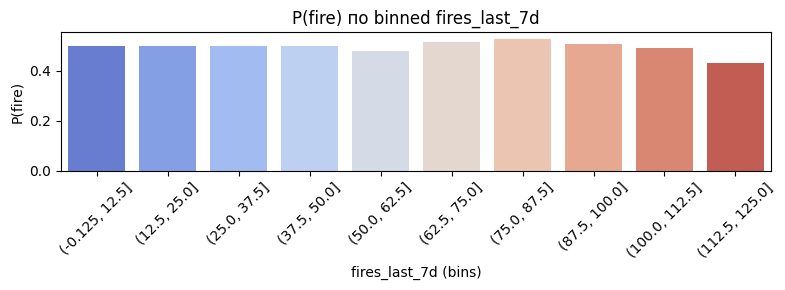

C:\Users\anatb\AppData\Local\Temp\ipykernel_13308\4278719907.py:24: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grp30 = df_sub.groupby('bin30')['target'].mean().reset_index()
C:\Users\anatb\AppData\Local\Temp\ipykernel_13308\4278719907.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='bin30', y='target', data=grp30, palette='viridis')


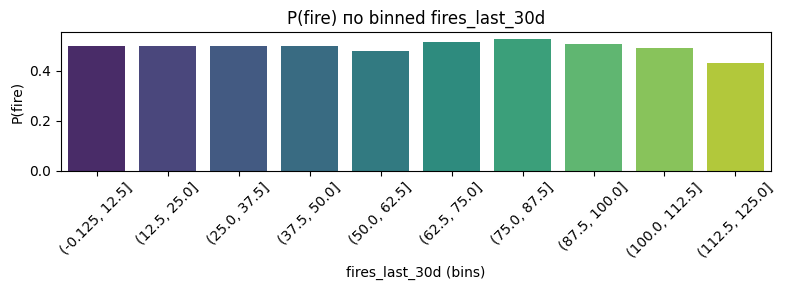

[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Info] Number of positive: 40000, number of negative: 40000
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000602 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 631
[LightGBM] [Info] Number of data points in the train set: 80000, number of used features: 6
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
ROC AUC: 0.8930
F1      : 0.8169

Feature importances:
cell_id_enc     5637
year            2973
month           2577
month_x_log7   

C:\Users\anatb\AppData\Local\Temp\ipykernel_13308\4278719907.py:87: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=imps.values, y=imps.index, palette='mako')


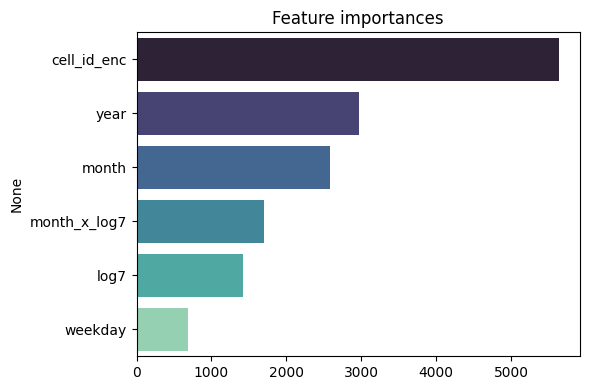

In [9]:
# 1.1 Распределения
fig, axes = plt.subplots(1, 2, figsize=(12,4))
sns.histplot(df_sub['fires_last_7d'], bins=30, ax=axes[0])
axes[0].set_title('Распределение fires_last_7d')
sns.histplot(df_sub['fires_last_30d'], bins=30, ax=axes[1])
axes[1].set_title('Распределение fires_last_30d')
plt.tight_layout()
plt.show()

# 1.2 P(fire) vs fires_last_7d (сгруппируем по корзинам)
df_sub['bin7'] = pd.cut(df_sub['fires_last_7d'], bins=10)
grp7 = df_sub.groupby('bin7')['target'].mean().reset_index()
plt.figure(figsize=(8,3))
sns.barplot(x='bin7', y='target', data=grp7, palette='coolwarm')
plt.xticks(rotation=45)
plt.title('P(fire) по binned fires_last_7d')
plt.ylabel('P(fire)')
plt.xlabel('fires_last_7d (bins)')
plt.tight_layout()
plt.show()

# 1.3 P(fire) vs fires_last_30d
df_sub['bin30'] = pd.cut(df_sub['fires_last_30d'], bins=10)
grp30 = df_sub.groupby('bin30')['target'].mean().reset_index()
plt.figure(figsize=(8,3))
sns.barplot(x='bin30', y='target', data=grp30, palette='viridis')
plt.xticks(rotation=45)
plt.title('P(fire) по binned fires_last_30d')
plt.ylabel('P(fire)')
plt.xlabel('fires_last_30d (bins)')
plt.tight_layout()
plt.show()

# # Фичи и таргет
# features = ['year','month','weekday','cell_id_enc','fires_last_7d','fires_last_30d']
# X = df_sub[features]
# y = df_sub['target']

# # Сплит
# X_train, X_val, y_train, y_val = train_test_split(
#     X, y, test_size=0.2, stratify=y, random_state=42
# )

# 1) Логарифмируем исторические фичи
df_sub['log7']  = np.log1p(df_sub['fires_last_7d'])
df_sub['log30'] = np.log1p(df_sub['fires_last_30d'])

# 2) Интеракционные фичи
df_sub['month_x_log7']  = df_sub['month'] * df_sub['log7']
df_sub['month_x_log30'] = df_sub['month'] * df_sub['log30']
df_sub['ratio_7_30']    = df_sub['fires_last_7d'] / (df_sub['fires_last_30d'] + 1)

# 3) Подготовка X/y с расширённым набором фич
features = ['cell_id_enc', 'year', 'month', 'weekday', 'log7', 'month_x_log7']

X = df_sub[features]
y = df_sub['target']

# 4) Сплит
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Обучение LightGBM
model = lgb.LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=7,
    num_leaves=31,
    min_data_in_leaf=20,
    random_state=42
)
model.fit(X_train[features], y_train)

# Предсказания и метрики
probs = model.predict_proba(X_val[features])[:,1]
preds = (probs > 0.5).astype(int)
print(f"ROC AUC: {roc_auc_score(y_val, probs):.4f}")
print(f"F1      : {f1_score(y_val, preds):.4f}")

# Важности признаков
imps = pd.Series(model.feature_importances_, index=features).sort_values(ascending=False)
print("\nFeature importances:")
print(imps)

plt.figure(figsize=(6,4))
sns.barplot(x=imps.values, y=imps.index, palette='mako')
plt.title("Feature importances")
plt.tight_layout()
plt.show()

In [14]:
import xarray as xr
import pandas as pd
import numpy as np
from pathlib import Path
from tqdm.auto import tqdm  # прогресс-бар

# 1) ваши df_sub уже загружен и в нём есть столбец date = dt.dt.date
df_sub["date"] = df_sub["dt"].dt.date

# 2) открываем файлы с чанками по времени (чтобы не держать всё в RAM сразу)
DATA_DIR = Path("datasets") / "data"
ds_i = xr.open_dataset(DATA_DIR / "data_stream-oper_stepType-instant.nc",
                       chunks={"valid_time": 1})
ds_a = xr.open_dataset(DATA_DIR / "data_stream-oper_stepType-accum.nc",
                       chunks={"valid_time": 1})

# 3) из instant берём только 12 UTC
hour = ds_i["valid_time"].dt.hour
ds_i_mid = ds_i.sel(valid_time=hour==12)[["t2m","u10","v10","latitude","longitude","valid_time"]]
ds_a_mid = ds_a.sel(valid_time=hour==12)[["tp","latitude","longitude","valid_time"]]

# 4) переименовываем valid_time → time для удобства
ds_i_mid = ds_i_mid.rename(valid_time="time")
ds_a_mid = ds_a_mid.rename(valid_time="time")

# 5) объединяем instant+accum
ds = xr.merge([ds_i_mid, ds_a_mid])
#  вычисляем скорость ветра
ds["windspeed_10m"] = np.sqrt(ds["u10"]**2 + ds["v10"]**2)
# готовим ячейки 0.5°
ds = ds.assign(
    lon_cell = (ds.longitude // 0.5) * 0.5,
    lat_cell = (ds.latitude  // 0.5) * 0.5,
    date     = ds["time"].dt.floor("D")
)

# 6) пройдём по каждому дню и соберём маленькие df
records = []
unique_dates = np.unique(ds["date"].values)
for day in tqdm(unique_dates, desc="Aggregating days"):
    # вырезаем один временной слой
    sub = ds.sel(time=str(day), method="nearest")  # xarray умеет по дате-строке
    # sub теперь dims=(latitude, longitude)
    # превращаем в DataFrame ровно для этого дня:
    if abs((sub.time.dt.floor("D") - np.datetime64(day))) > np.timedelta64(1, "h"):
        # нет подходящего часа — пропускаем
        continue
    df_day = sub.to_dataframe().reset_index()
    # группируем по ячейке и датe (датa одна и та же)
    df_agg = df_day.groupby(["date","lon_cell","lat_cell"], as_index=False).agg({
        "t2m":           "mean",
        "tp":            "sum",
        "windspeed_10m": "mean"
    })
    records.append(df_agg)

# 7) собираем итоговый датафрейм
df_weather = pd.concat(records, ignore_index=True)

# 8) мержим в df_sub
df = df_sub.merge(df_weather, on=["date","lon_cell","lat_cell"], how="left")

# 9) заполняем пропуски
for c in ["t2m","tp","windspeed_10m"]:
    df[c].fillna(df[c].mean(), inplace=True)

# 10) строим скользящие окна уже в pandas
df = df.sort_values("dt")
for w in (7,14,30):
    df[f"t2m_{w}d"] = (
        df.groupby(["lon_cell","lat_cell"])["t2m"]
          .rolling(w, min_periods=1).mean()
          .reset_index(0,drop=True)
    )
    df[f"tp_{w}d"] = (
        df.groupby(["lon_cell","lat_cell"])["tp"]
          .rolling(w, min_periods=1).sum()
          .reset_index(0,drop=True)
    )
    df[f"wind_{w}d"] = (
        df.groupby(["lon_cell","lat_cell"])["windspeed_10m"]
          .rolling(w, min_periods=1).mean()
          .reset_index(0,drop=True)
    )

# 11) сохраняем результат
df.to_csv("data_with_weather_midday.csv", index=False)
print("✅ Сохранён data_with_weather_midday.csv")


C:\Users\anatb\AppData\Local\Temp\ipykernel_13308\1411253285.py:12: UserWarning: The specified chunks separate the stored chunks along dimension "valid_time" starting at index 1. This could degrade performance. Instead, consider rechunking after loading.
  ds_i = xr.open_dataset(DATA_DIR / "data_stream-oper_stepType-instant.nc",
C:\Users\anatb\AppData\Local\Temp\ipykernel_13308\1411253285.py:14: UserWarning: The specified chunks separate the stored chunks along dimension "valid_time" starting at index 1. This could degrade performance. Instead, consider rechunking after loading.
  ds_a = xr.open_dataset(DATA_DIR / "data_stream-oper_stepType-accum.nc",
Aggregating days: 100%|██████████| 3704/3704 [8:24:30<00:00,  8.17s/it]  


ValueError: You are trying to merge on object and datetime64[ns] columns for key 'date'. If you wish to proceed you should use pd.concat

In [ ]:
# train_from_csv.py

import pandas as pd
import lightgbm as lgb
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, f1_score

# 1) Загружаем готовый датасет
df = pd.read_csv("data_with_weather.csv", parse_dates=["dt","date"])

# 2) Определяем фичи и таргет
features = [
    'cell_id_enc','year','month','weekday','log7','month_x_log7',
    'temperature_2m','relativehumidity_2m','precipitation','windspeed_10m',
    'temp_7d','prec_7d','temp_14d','prec_14d','temp_30d','prec_30d'
]
X = df[features]
y = df['target']

# 3) Сплит и обучение
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
model = lgb.LGBMClassifier(
    n_estimators=500, learning_rate=0.05, max_depth=7, random_state=42
)
model.fit(X_train, y_train)

# 4) Оценка
probs = model.predict_proba(X_val)[:,1]
preds = (probs>0.5).astype(int)
print(f"ROC AUC: {roc_auc_score(y_val, probs):.4f}")
print(f"F1      : {f1_score(y_val, preds):.4f}")

# 5) Важности признаков
imps = pd.Series(model.feature_importances_, index=features).sort_values(ascending=False)
plt.figure(figsize=(6,4))
sns.barplot(x=imps.values, y=imps.index, palette="mako")
plt.title("Feature importances with weather")
plt.tight_layout()
plt.show()
